In [144]:
import numpy as np
import pandas as pd
import missingno as msno
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from statsmodels.stats.proportion import proportions_ztest
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder
from sklearn.model_selection import train_test_split, RandomizedSearchCV, GridSearchCV
from missforest import MissForest
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier
from sklearn.inspection import permutation_importance
import shap
from statsmodels.tools.tools import add_constant
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.model_selection import cross_val_score
from scipy.stats import skew, kurtosis
from sklearn.preprocessing import RobustScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score
from imblearn.metrics import specificity_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

In [145]:
# FUNCIONES
## Formato 5 decimales
pd.options.display.float_format = '{:,.5f}'.format 

## Metricas de clasificacion
def metricas_clas(y_train, y_test, y_pred_train, y_pred_test):
    # Calcular métricas para el conjunto de entrenamiento
    train_accuracy = accuracy_score(y_train, y_pred_train)
    train_f1 = f1_score(y_train, y_pred_train)
    train_precision = precision_score(y_train, y_pred_train)
    train_recall = recall_score(y_train, y_pred_train)
    train_specificity = specificity_score(y_train, y_pred_train)

    # Calcular métricas para el conjunto de prueba
    test_accuracy = accuracy_score(y_test, y_pred_test)
    test_f1 = f1_score(y_test, y_pred_test)
    test_precision = precision_score(y_test, y_pred_test)
    test_recall = recall_score(y_test, y_pred_test)
    test_specificity = specificity_score(y_test, y_pred_test)

    # Calcular la diferencia entre métricas de entrenamiento y prueba
    diff_accuracy = train_accuracy - test_accuracy
    diff_f1 = train_f1 - test_f1
    diff_precision = train_precision - test_precision
    diff_recall = train_recall - test_recall
    diff_specificity = train_specificity - test_specificity

    # Crear un DataFrame con los resultados
    metrics_df = pd.DataFrame([[train_accuracy,train_recall,train_specificity,train_precision,train_f1],
                               [test_accuracy, test_recall, test_specificity, test_precision,test_f1],
                               [diff_accuracy, diff_recall, diff_specificity, diff_precision, diff_f1]],
                              columns = ['Accuracy', 'Recall', 'Specificity', 'Precision', 'F1'],
                              index = ['Train','Test', 'Diferencia'])

    return metrics_df

# **0. CONTEXTO Y CARGA DATOS**

Fuente: https://github.com/4GeeksAcademy/linear-regression-project-tutorial/blob/main/README.es.md

Variables:
- age. Edad del beneficiario principal (numérico)

- sex. Género del beneficiario principal (categórico)

- bmi. índice de masa corporal (numérico)

- children. Número de niños/dependientes cubiertos por un seguro médico (numérico)

- smoker. ¿Es fumador? (categórico)

- region. Área residencial del beneficiario en USA: noreste, sureste, suroeste, noroeste (categórico)

- charges. Prima del seguro médico (numérico)

In [146]:
#Cargamos la base de datos en crudo
df=pd.read_csv("https://breathecode.herokuapp.com/asset/internal-link?id=929&path=medical_insurance_cost.csv")
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [147]:
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.90000,0,yes,southwest,"16,884.92400"
1,18,male,33.77000,1,no,southeast,"1,725.55230"
2,28,male,33.00000,3,no,southeast,"4,449.46200"
3,33,male,22.70500,0,no,northwest,"21,984.47061"
4,32,male,28.88000,0,no,northwest,"3,866.85520"


# **1. CRIBADO MANUAL**

## 1.1. Verificar valores

### 1.1.1. Unicos

In [148]:
# Valores unicos por cada columna
unicos=df.nunique()
print("No hay columnas con valores únicos" if sum(unicos==1)==0 else "Hay columnas con valores únicos")

No hay columnas con valores únicos


### 1.1.2. Eliminación de filas y columnas duplicadas

In [149]:
fil_dup=df.duplicated(keep="last") # keep=last: Fila duplicada ultima aparicion
print("No hay filas duplicadas" if fil_dup.sum()==0 else f"Hay {fil_dup.sum()} filas duplicadas")

Hay 1 filas duplicadas


In [150]:
#Mostramos un df con todas las filas duplicadas
todas=df.duplicated(keep=False)
df.iloc[todas[todas==True].index].T

,195,581
age,19,19
sex,male,male
bmi,30.59000,30.59000
children,0,0
smoker,no,no
region,northwest,northwest
charges,"1,639.56310","1,639.56310"


In [151]:
#Eliminamos las filas duplicadas
df.drop_duplicates(keep="last", inplace=True)
## Verificamos que se han eliminado correctamente
fil_dup=df.duplicated(keep="last") #Fila duplicada ultima aparicion
print("No hay filas duplicadas" if fil_dup.sum()==0 else f"Hay {fil_dup.sum()} filas duplicadas")

No hay filas duplicadas


In [152]:
#Trasponemos las columnas para verificar que toda la fila (variable) no sea igual a otra
col_dup=df.T.duplicated(keep="last")
print("No hay variables exactamente iguales" if col_dup.sum()==0 else f"Hay {fil_dup.sum()} variables exactamente iguales")

No hay variables exactamente iguales


## 1.2. Verificar missing values

### 1.2.1. Datos enmascarados(categoricas)

In [153]:
#Datos enmascarados (variables categoricas)
columnas=df.select_dtypes(include='object')
for col in columnas:
    print("-"*20)
    print(f"Columna: {col}")
    print("-"*20)
    print(df[col].value_counts(normalize=True)*100)

--------------------
Columna: sex
--------------------
sex
male     50.48616
female   49.51384
Name: proportion, dtype: float64
--------------------
Columna: smoker
--------------------
smoker
no    79.50636
yes   20.49364
Name: proportion, dtype: float64
--------------------
Columna: region
--------------------
region
southeast   27.22513
southwest   24.30815
northwest   24.23336
northeast   24.23336
Name: proportion, dtype: float64


### 1.2.2. Datos enmascarados(numericos)

In [154]:
df.select_dtypes(["int64", "float64"]).describe().T

,count,mean,std,min,25%,50%,75%,max
age,"1,337.00000",39.22214,14.04433,18.00000,27.00000,39.00000,51.00000,64.00000
bmi,"1,337.00000",30.66345,6.10047,15.96000,26.29000,30.40000,34.70000,53.13000
children,"1,337.00000",1.09574,1.20557,0.00000,0.00000,1.00000,2.00000,5.00000
charges,"1,337.00000","13,279.12149","12,110.35966","1,121.87390","4,746.34400","9,386.16130","16,657.71745","63,770.42801"


### 1.2.3. Visualización

In [155]:
#Mostramos columnas con valores nulos
nulos=df.isna().sum()/len(df)*100
nulos[nulos>0.1]

Series([], dtype: float64)

[]

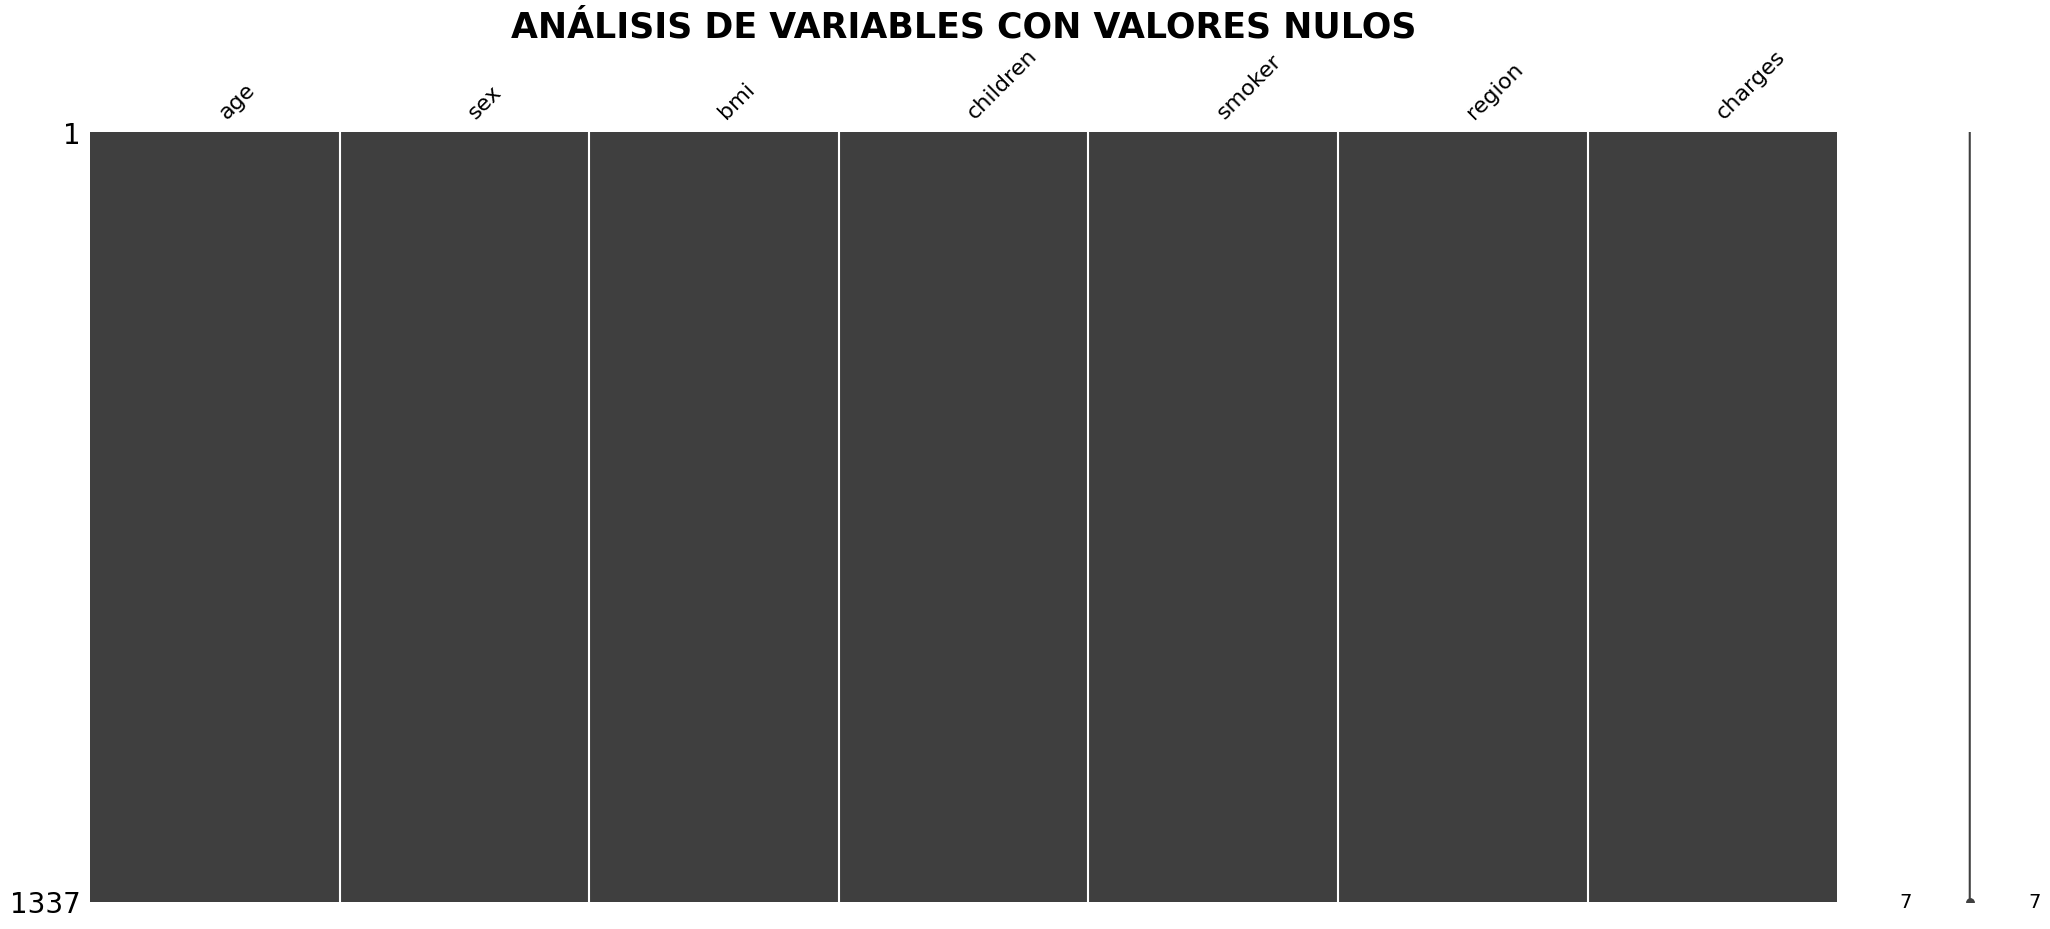

In [156]:
#Gráficamente
msno.matrix(df)
plt.title("ANÁLISIS DE VARIABLES CON VALORES NULOS", fontweight="bold", size=25)
plt.plot()

## 1.3. Codificar variables categoricas

In [157]:
# Visualizamos valores unicos y numero de categorías
for col in df.select_dtypes("object"):
    print(f"\n{'='*30}")
    print(f"COLUMNA: {col.upper()}")
    print(f"{'='*30}")
    
    # Valores únicos
    valores = df[col].dropna().unique() # → Elimina los NaN antes de obtener los valores únicos
    print(f"Número de categorías: {len(valores)}")
    print(f"Valores: {valores}\n")  


COLUMNA: SEX
Número de categorías: 2
Valores: ['female' 'male']


COLUMNA: SMOKER
Número de categorías: 2
Valores: ['yes' 'no']


COLUMNA: REGION
Número de categorías: 4
Valores: ['southwest' 'southeast' 'northwest' 'northeast']



### 1.3.1. One hot encoding

#### A) Sex

In [159]:
print("PRIMA MEDIA POR GÉNERO: ")
print("-"*25)
print(df.groupby("sex")["charges"].mean())

PRIMA MEDIA POR GÉNERO: 
-------------------------
sex
female   12,569.57884
male     13,974.99886
Name: charges, dtype: float64


In [160]:
# Llamamos a la función
## - drop='first' elimina una cat 
## - parse_output=False devuelve array
ohe = OneHotEncoder(sparse_output=False, drop='first', dtype=int)

# Ajustamos y transformamos
encoded_data = ohe.fit_transform(df[["sex"]]) 

# Añadimos al df
nombre_col = ohe.get_feature_names_out(["sex"])
sex = pd.DataFrame(encoded_data, columns=nombre_col)

df=pd.merge(df, sex, on=df.index, how='right').drop(columns=["sex", "key_0"]).rename(columns={"sex_male": "male"})
df.columns

Index(['age', 'bmi', 'children', 'smoker', 'region', 'charges', 'male'], dtype='object')

#### B) Smoker

In [161]:
print("PRIMA MEDIA PARA FUMADORES: ")
print("-"*25)
print(df.groupby("smoker")["charges"].mean())

PRIMA MEDIA PARA FUMADORES: 
-------------------------
smoker
no     8,440.66031
yes   32,050.23183
Name: charges, dtype: float64


In [162]:
# Ajustamos y transformamos
encoded_data = ohe.fit_transform(df[["smoker"]]) 

# Añadimos al df
nombre_col = ohe.get_feature_names_out(["smoker"])
smoker = pd.DataFrame(encoded_data, columns=nombre_col)

df=pd.merge(df, smoker, on=df.index, how='right').drop(columns=["smoker", "key_0"]).rename(columns={"smoker_yes": "smoker"})
df.columns

Index(['age', 'bmi', 'children', 'region', 'charges', 'male', 'smoker'], dtype='object')

#### C) Region

In [163]:
print("PRIMA MEDIA POR REGIÓN: ")
print("-"*25)
df.groupby("region")["charges"].mean()

PRIMA MEDIA POR REGIÓN: 
-------------------------


region
northeast   13,406.38452
northwest   12,450.84084
southeast   14,735.41144
southwest   12,346.93738
Name: charges, dtype: float64

In [165]:
# Ajustamos y transformamos
encoded_data = ohe.fit_transform(df[["region"]]) 

# Añadimos al df
nombre_col = ohe.get_feature_names_out(["region"])
region = pd.DataFrame(encoded_data, columns=nombre_col)

df=pd.merge(df, region, on=df.index, how='right').drop(columns=["key_0"]).rename(columns={"region_northwest": "northwest", "region_southeast": "southeast", "region_southwest": "southwest"})
df.columns

Index(['age', 'bmi', 'children', 'region', 'charges', 'male', 'smoker',
       'northwest', 'southeast', 'southwest'],
      dtype='object')

## 1.4. Análisis Univariante

In [167]:
df.head(3).drop(columns="region")

,age,bmi,children,charges,male,smoker,northwest,southeast,southwest
0,19,27.90000,0,"16,884.92400",0,1,0,0,1
1,18,33.77000,1,"1,725.55230",1,0,0,1,0
2,28,33.00000,3,"4,449.46200",1,0,0,1,0


### 1.4.1. Variables numéricas

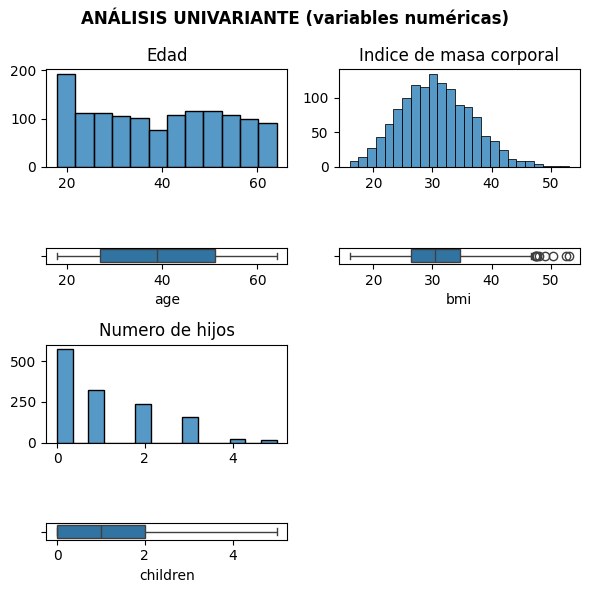

In [168]:
fig, axis = plt.subplots(4, 2, figsize = (6, 6), gridspec_kw={'height_ratios': [6, 1, 6, 1]}) #height_ratios: cambiar tamaño relativo de los graficos

#Primera Fila
sns.histplot(ax = axis[0, 0], data = df, x = "age").set(xlabel = None, ylabel = None)
sns.boxplot(ax = axis[1, 0], data = df, x = "age")
axis[0, 0].set_title("Edad")
sns.histplot(ax = axis[0, 1], data = df, x = "bmi").set(xlabel = None, ylabel = None)
sns.boxplot(ax = axis[1, 1], data = df, x = "bmi")
axis[0, 1].set_title("Indice de masa corporal")

#Segunda fila
sns.histplot(ax = axis[2, 0], data = df, x = "children").set(xlabel = None, ylabel = None)
sns.boxplot(ax = axis[3, 0], data = df, x = "children")
axis[2, 0].set_title("Numero de hijos")
axis[2,1].remove()
axis[3,1].remove()

fig.suptitle("ANÁLISIS UNIVARIANTE (variables numéricas)", fontweight="bold")
plt.tight_layout()
plt.show()

No se aprecian valores extremos ni extraños dentro de las variables numéricas.

### 1.4.2. Variables categóricas

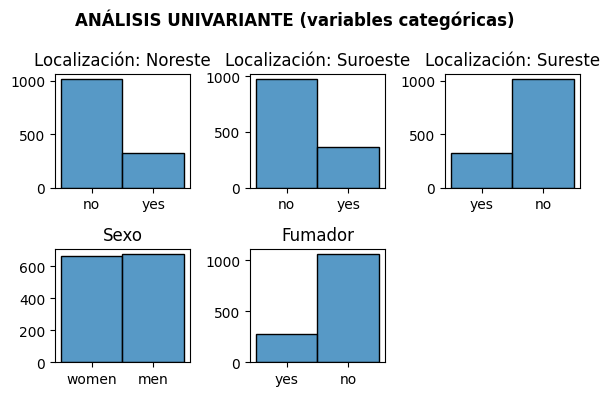

In [169]:
fig, axis = plt.subplots(2, 3, figsize = (6, 4))

#Primera Fila
sns.histplot(df["northwest"].replace({0: "no", 1:"yes"}), ax = axis[0, 0]).set(xlabel = None, ylabel = None)
axis[0, 0].set_title("Localización: Noreste")
sns.histplot(df["southeast"].replace({0: "no", 1:"yes"}), ax = axis[0, 1]).set(xlabel = None, ylabel = None)
axis[0, 1].set_title("Localización: Suroeste")
sns.histplot(df["southwest"].replace({0: "no", 1:"yes"}), ax = axis[0, 2]).set(xlabel = None, ylabel = None)
axis[0, 2].set_title("Localización: Sureste")

#Segunda fila
sns.histplot(df["male"].replace({0: "women", 1:"men"}), ax = axis[1, 0]).set(xlabel = None, ylabel = None)
axis[1, 0].set_title("Sexo")
sns.histplot(df["smoker"].replace({0: "no", 1:"yes"}), ax = axis[1, 1]).set(xlabel = None, ylabel = None)
axis[1, 1].set_title("Fumador")
axis[1,2].remove()

fig.suptitle("ANÁLISIS UNIVARIANTE (variables categóricas)", fontweight="bold")
plt.tight_layout()
plt.show()

### 1.4.3. Target 

[]

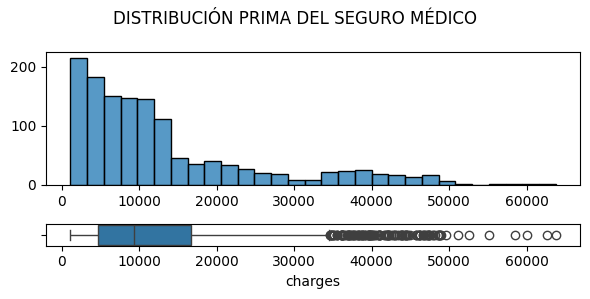

In [170]:
#Configuración subplots
fig, axis = plt.subplots(2, 1, figsize = (6, 3), gridspec_kw={'height_ratios': [6, 1]}) #height_ratios: cambiar tamaño relativo de los graficos

#Representación
sns.histplot(df["charges"], bins="auto", ax=axis[0]).set(xlabel = None, ylabel = None)
sns.boxplot(ax = axis[1], data = df, x = "charges")
fig.suptitle("Distribución prima del seguro médico".upper())
plt.tight_layout()
plt.plot()

Se aprecia como al tratar la variable ``charges`` en niveles, aparece un número importante de outliers para los niveles altos de prima. Para solucionarlo, basta con tomar logaritmos.

[]

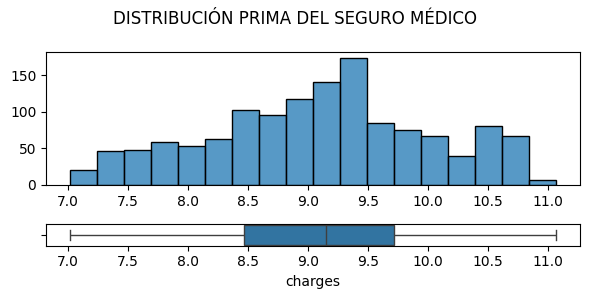

In [174]:
#Configuración subplots
fig, axis = plt.subplots(2, 1, figsize = (6, 3), gridspec_kw={'height_ratios': [6, 1]}) #height_ratios: cambiar tamaño relativo de los graficos

#Representación
sns.histplot(np.log(df["charges"]), bins="auto", ax=axis[0]).set(xlabel = None, ylabel = None)
sns.boxplot(x=np.log(df["charges"]), ax = axis[1])
fig.suptitle("Distribución prima del seguro médico".upper())
plt.tight_layout()
plt.plot()

In [175]:
#Aplicamos la transformación
df["charges"]=np.log(df["charges"])

## 1.5. Análisis Multivariante

In [ ]:
df.columns

Index(['age', 'bmi', 'children', 'charges', 'male', 'smoker', 'northwest',
       'southeast', 'southwest'],
      dtype='object')

### 1.5.1. Numérica-numérica

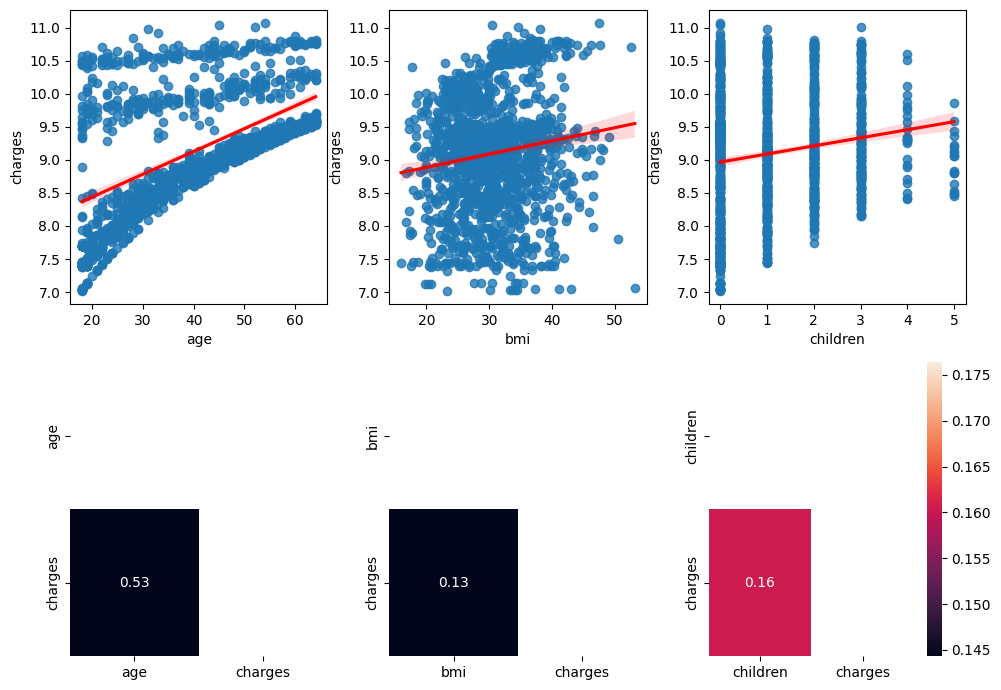

In [177]:
#Charges vs age-bmi-children
fig, axis = plt.subplots(2, 3, figsize = (10, 7))

# Diagrama de dispersión múltiple: Regresión MCO y matriz de correlacion
## AGE
sns.regplot(ax = axis[0, 0], data = df, x = "age", y = "charges", line_kws=dict(color="r"))
sns.heatmap(df[["age", "charges"]].corr(), mask=np.triu(np.ones_like(df[["age", "charges"]].corr(), dtype=bool)), 
            annot = True, fmt = ".2f", ax = axis[1, 0], cbar = False)
## BMI
sns.regplot(ax = axis[0, 1], data = df, x = "bmi", y = "charges", line_kws=dict(color="r"))
sns.heatmap(df[["bmi", "charges"]].corr(), mask=np.triu(np.ones_like(df[["bmi", "charges"]].corr(), dtype=bool)), 
            annot = True, fmt = ".2f", ax = axis[1, 1], cbar = False)
## CHILDREN
sns.regplot(ax = axis[0, 2], data = df, x = "children", y = "charges", line_kws=dict(color="r"))
sns.heatmap(df[["children", "charges"]].corr(), mask=np.triu(np.ones_like(df[["children", "charges"]].corr(), dtype=bool)), 
            annot = True, fmt = ".2f", ax = axis[1, 2]) #Anclamos cbar de la ultima variable

# Ajustar el layout
plt.tight_layout()

# Mostrar el plot
plt.show()

Podemos observar una fuerte relación positiva entre todas las variables numéricas y la target, de forma más intensa en el caso de ``age``.

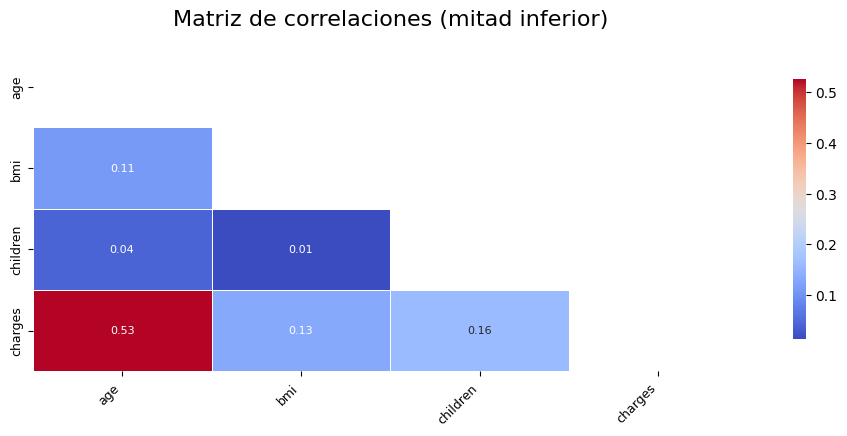

In [176]:
#Matriz de correlacion
df_corr=df[['age', 'bmi', 'children', 'charges']]
# Mostramos matriz con correcciones
plt.figure(figsize=(10, 5))
sns.heatmap(
    df_corr.corr(), mask=np.triu(np.ones_like(df_corr.corr(), dtype=bool)), 
    cmap='coolwarm',
    annot=True, fmt=".2f", linewidths=.5,
    cbar_kws={"shrink": .8},
    annot_kws={"size": 8}
)
plt.title("Matriz de correlaciones (mitad inferior)", fontsize=16, pad=15)
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.yticks(fontsize=9)
plt.tight_layout(pad=3.0)
plt.show()

### 1.5.2. Numérica-categórica

[]

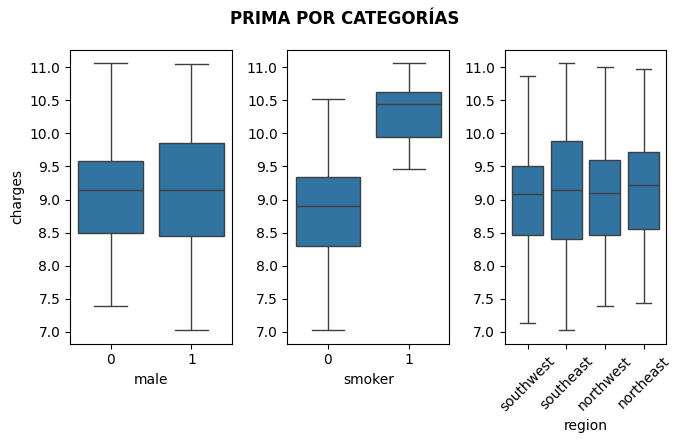

In [187]:
#Charges vs sex-smoker-region
fig, axis = plt.subplots(1, 3, figsize = (7, 4))

#Boxplot por categoría
sns.boxplot(ax=axis[0], data=df, x="male", y="charges") 
sns.boxplot(ax=axis[1], data=df, x="smoker", y="charges").set(ylabel=None)
sns.boxplot(ax=axis[2], data=df, x="region", y="charges").set(ylabel=None)
fig.suptitle("Prima por categorías".upper(), fontweight="bold")
plt.tight_layout() #Añadir espacio entre gráficos
plt.xticks(rotation=45)
plt.plot()

### 1.5.3. Gráfico resumen

In [188]:
#Eliminamos region
df.drop(columns="region", inplace=True)

In [190]:
df.columns

Index(['age', 'bmi', 'children', 'charges', 'male', 'smoker', 'northwest',
       'southeast', 'southwest'],
      dtype='object')

[]

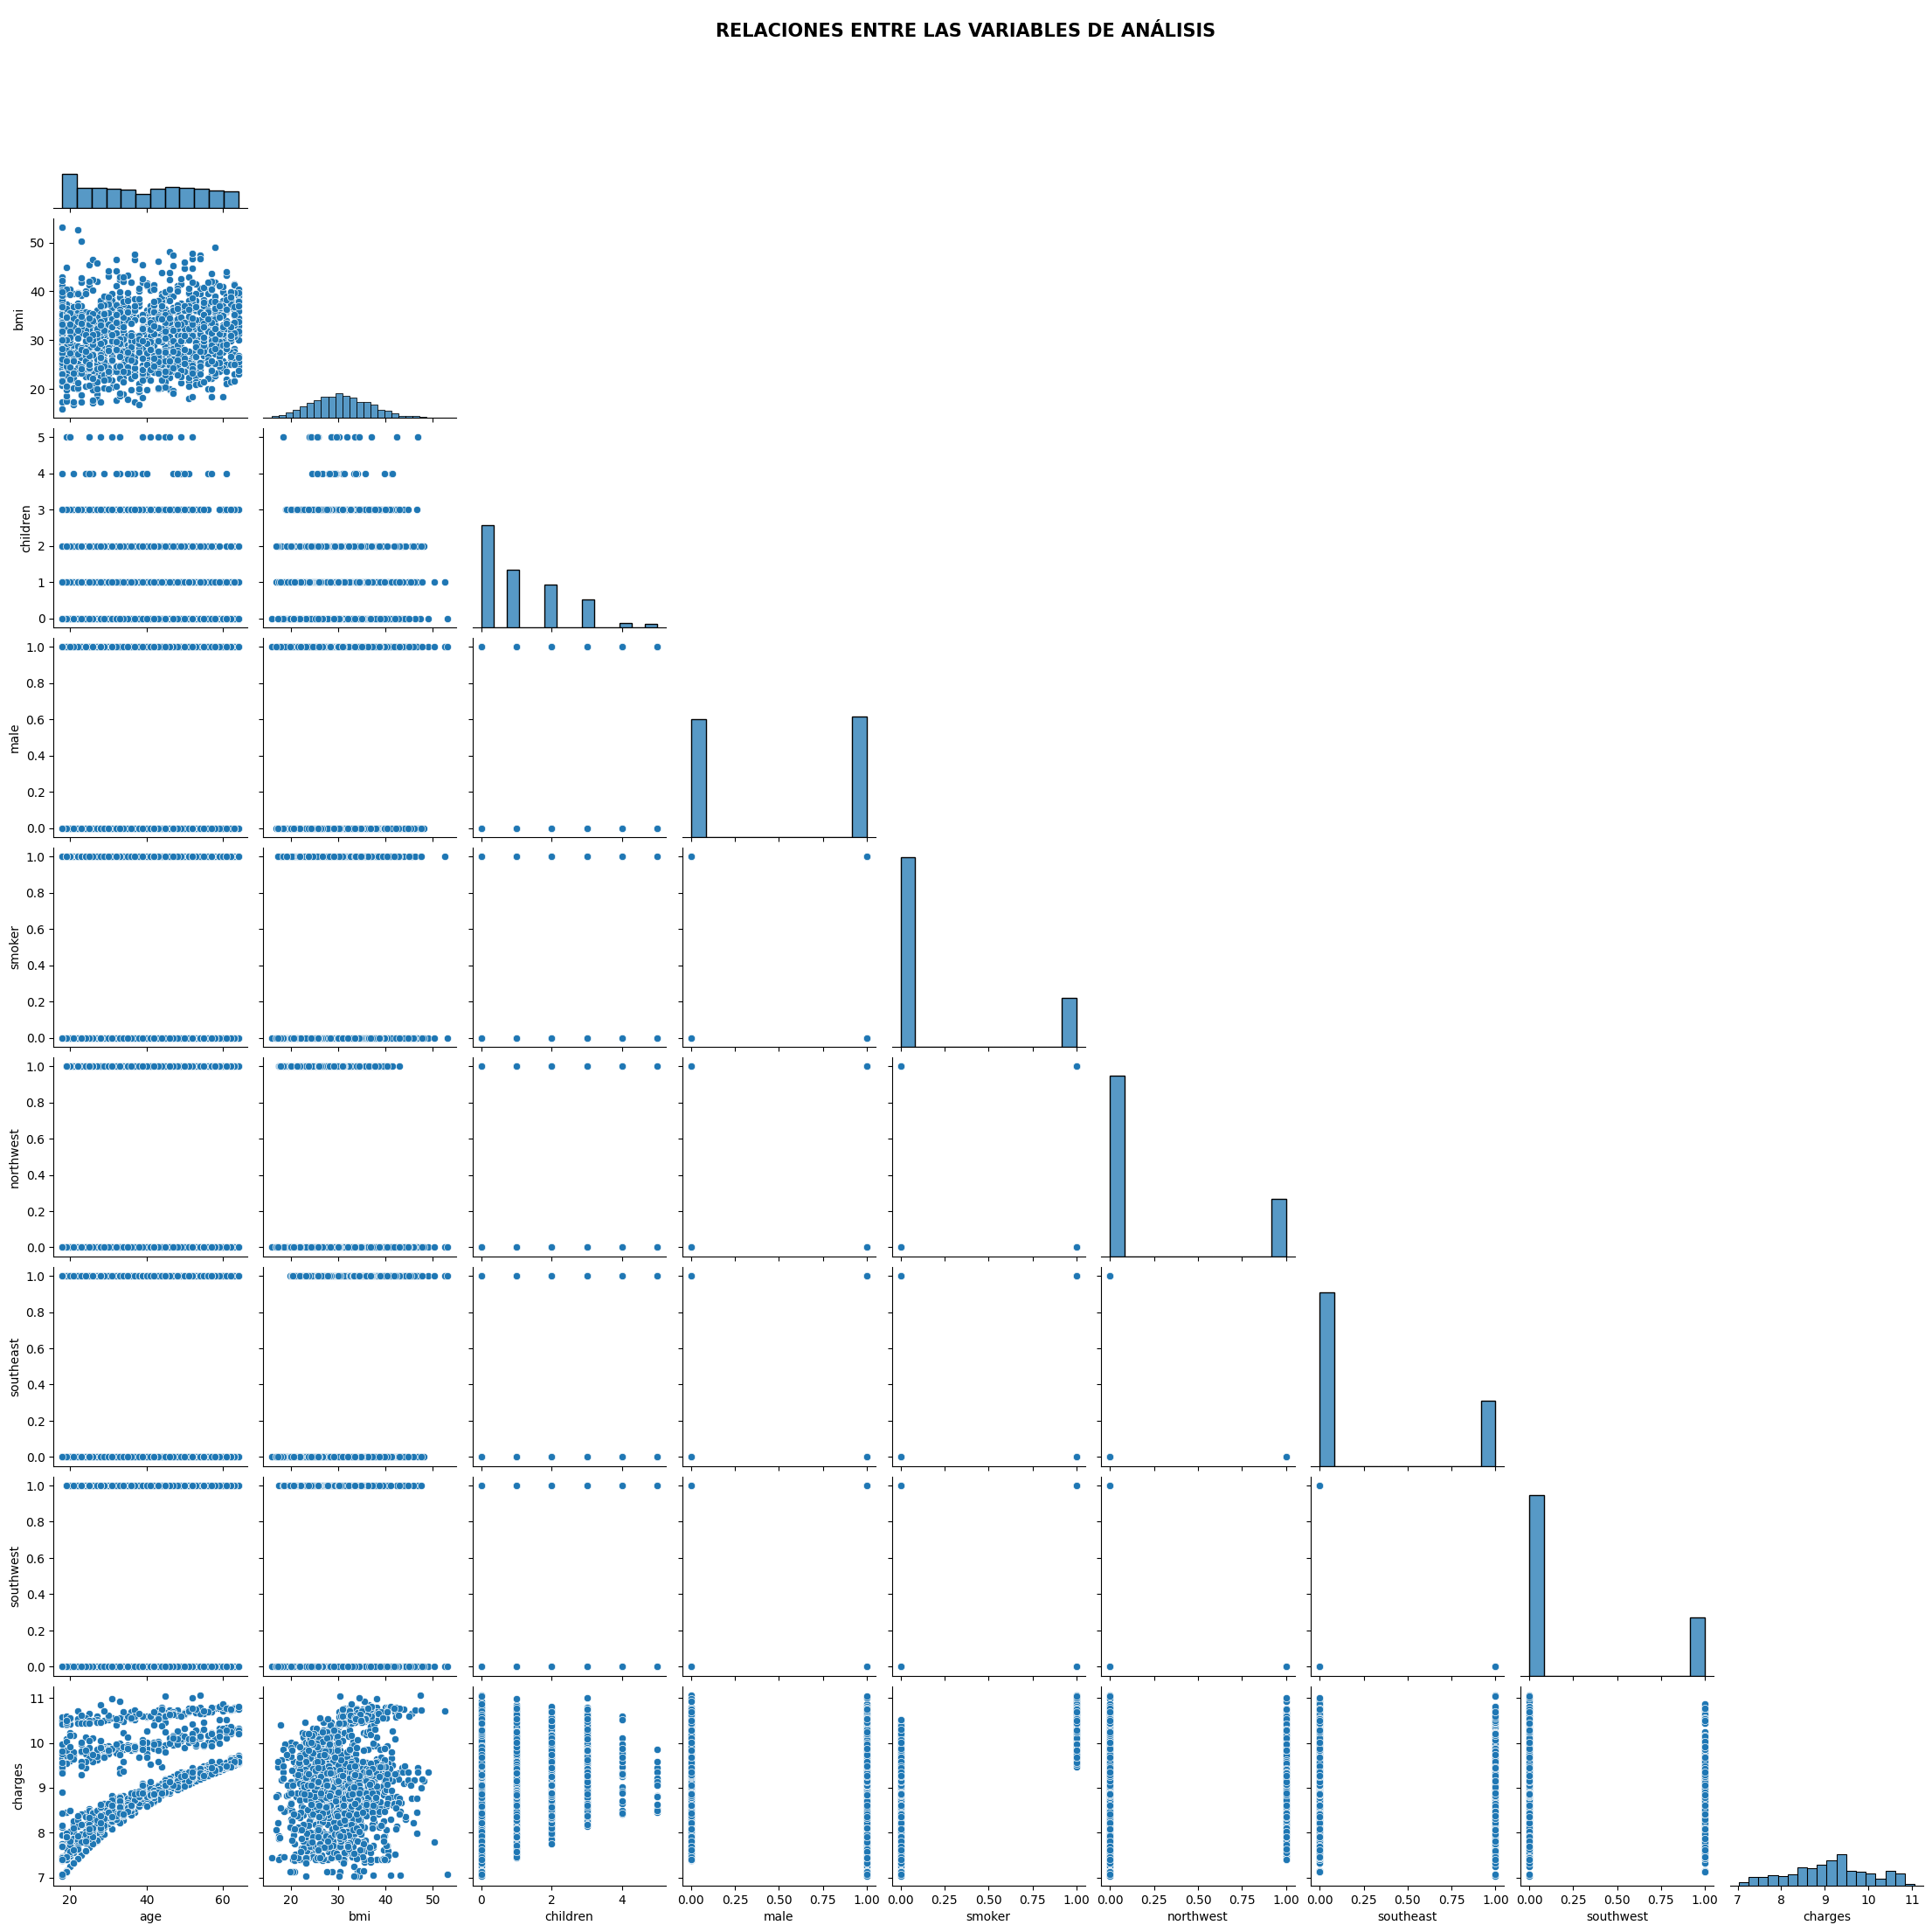

In [192]:
orden=['age', 'bmi', 'children', 'male', 'smoker', 'northwest',
       'southeast', 'southwest', 'charges']
sns.pairplot(data=df[orden], corner=True)
plt.suptitle("Relaciones entre las variables de análisis".upper(), fontweight="bold", size=15)
plt.plot()

## 1.6. División Train-Test

In [65]:
#Diviisón de la base de datos
X = df.drop('charges',axis=1)
y = df['charges']
X_train, X_test, y_train, y_test=train_test_split(X,y, test_size=0.2, random_state=42) #random_state establece una semilla para que la division aleatoria sea la misma
X_train.head()

,age,bmi,children,male,smoker,northwest,southeast,southwest
1113,23,24.51000,0,1,0,0,0,0
967,21,25.74500,2,1,0,0,0,0
598,52,37.52500,2,0,0,1,0,0
170,63,41.47000,0,1,0,0,1,0
275,19,20.61500,2,1,0,1,0,0


# **2. SELECCIÓN DE CARACTERÍSTICAS**

## 2.1. Aplicar métodos

### 2.1.1. Feature Importance

El **feature importance** en RandomForestClassifier se calcula mediante reducción de impureza promedio a través de todos los árboles del bosque.

Cómo se calcula:
1. Para cada árbol individual: Se mide cuánto reduce cada feature la impureza (Gini o entropía) cuando se usa para hacer splits

2. Ponderación por muestras: La reducción se pondera por el número de muestras que pasan por ese nodo

3. Promedio entre árboles: Se promedian las importancias de cada feature a través de todos los árboles del bosque

4. Normalización: Los valores finales se normalizan para que sumen 1
Fórmula de reducción de impureza:
La importancia de una feature se basa en esta ecuación (mencionada en el texto):

$\text{Reducción} = \frac{N_t}{N} I_t - \frac{N_{t_L}}{N} I_L - \frac{N_{t_R}}{N} I_R$

Donde:
- $N$: total de muestras

- $N_t$ y I_t: muestras e impureza en el nodo actual

- $N_{tL}$ y $I_{tL}$: muestras e impureza en hijos izquierdo

- $N_{tR}$ y $I_{tR}$: muestras e impureza en hijos derechos

Fuente: https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestClassifier.html

In [70]:
# Entrenamiento de RF
model = RandomForestClassifier(random_state=42,n_jobs=-1).fit(X_train_sel, y_train_sel)
# Importancia de características
importances = model.feature_importances_/model.feature_importances_.sum()*100
# Mostramos resultados
df_rf_imp = pd.DataFrame({'feature': X_train_sel.columns,'rf_importance': importances}).sort_values(by='rf_importance', ascending=False)
df_rf_imp

,feature,rf_importance
5,duration,31.299773
11,euribor3m,12.204074
0,age,9.759281
12,nr.employed,6.699669
6,campaign,4.494637
1,job,4.350603
4,day_of_week,4.283900
2,education,4.163104
13,y(-1),3.425494
8,emp.var.rate,2.909989


### 2.1.2. Permutation Importance

**Permutation importance** proporciona el cambio en la métrica de scoring seleccionada cuando alteramos los valores de las características de estudio. 

Como en nuestro caso estamos trabajando con información económica, vamos a centrarnos en la métrica de f1 score para minimizar FP en los que el banco estaria invirtiendo y realmente no son clientes, máximizando el numero de VP.

Informacion sobre scorings: https://scikit-learn.org/stable/modules/model_evaluation.html#scoring-string-names

Fuente: https://scikit-learn.org/stable/modules/generated/sklearn.inspection.permutation_importance.html

In [71]:
# Para esta técnica y la de shap se necesita conjunto de validación
X_train1, X_val, y_train1, y_val = train_test_split(X_train_sel, y_train_sel, test_size=0.2, random_state=42)
# Entrenamos el modelo que va a porporcionarnos las predicciones por cada alteracion
model_xgb = XGBClassifier(objective='binary:logistic', random_state=42).fit(X_train1, y_train1)
# Intanciamos permitation forest
perm = permutation_importance(model_xgb, X_val, y_val, n_repeats=10, random_state=42, n_jobs=-1, scoring='f1')
## Extraemos los valores a un df
df_perm_imp = pd.DataFrame({'feature': X_train1.columns, 'perm_imp': perm.importances_mean*100}).sort_values('perm_imp', ascending=False)
df_perm_imp

,feature,perm_imp
5,duration,27.375096
8,emp.var.rate,21.353352
12,nr.employed,12.471832
13,y(-1),6.229329
11,euribor3m,3.578421
3,month,3.220710
0,age,2.629254
18,telephone,2.462063
4,day_of_week,1.503684
10,cons.conf.idx,1.467950


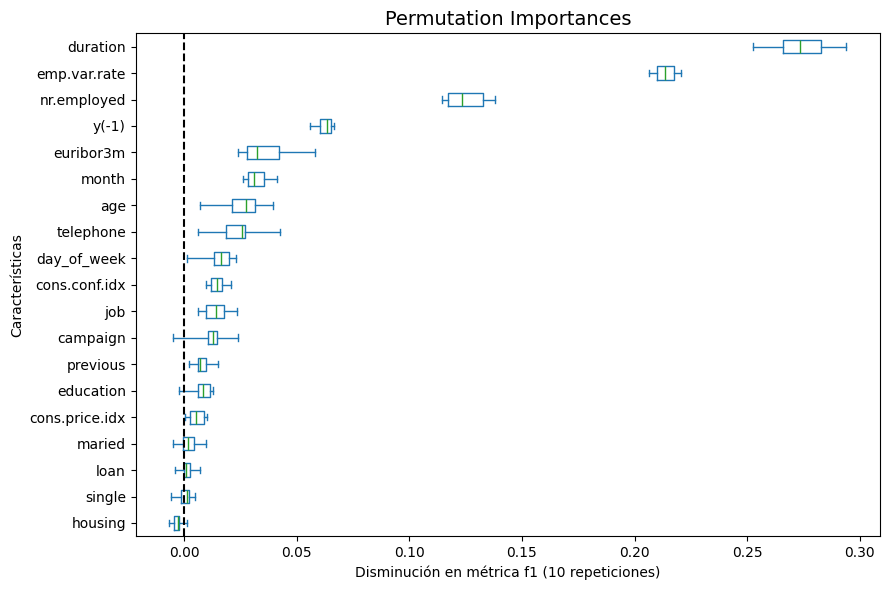

In [72]:
# REPRESENTACIÓN GRÁFICA
## Orden de las variables (de menor a mayor importancia media):
### - asegura que el gráfico final esté ordenado
sorted_idx = perm.importances_mean.argsort()

## DataFrame para el Box Plot
### - perm.importances devuelve los n cambios en f1 de la caract x 
importances_df = pd.DataFrame(
    perm.importances[sorted_idx].T,
    columns=X_train_sel.columns[sorted_idx] 
)
importances_df

## Gráfico
fig, ax = plt.subplots(figsize=(9,6))

### Usamos .plot.box() directamente sobre el DataFrame (columna por columna)
ax = importances_df.plot.box(vert=False, whis=10, ax=ax) # vert=False -> gráfico horizontal
ax.set_title("Permutation Importances", fontsize=14)
ax.set_ylabel("Características")
ax.axvline(x=0, color="k", linestyle="--") # Línea vertical en 0 (sin ganancia/pérdida)
ax.set_xlabel("Disminución en métrica f1 (10 repeticiones)") 
fig.tight_layout()
plt.show()

### 2.1.3. SHAP

SHAP utiliza valores de Shapley de la teoría de juegos cooperativos para asignar crédito a cada característica. Los valores SHAP miden cuánto contribuye cada característica a la predicción del modelo, proporcionando una interpretación consistente del comportamiento del modelo. El explainer integra sobre múltiples muestras de fondo para estimar valores SHAP aproximados que suman la diferencia entre la salida esperada del modelo y la salida actual: $f(x) - E[f(x)]$ 

Fuente: https://shap.readthedocs.io/en/latest/generated/shap.Explainer.html#shap.Explainer

In [73]:
# Ajustamos un modelo predictor para analizar la importancia de cada caract.
model_gbc = GradientBoostingClassifier(random_state=42).fit(X_train1, y_train1) 
# Instanciamos el shap explainer y extraemos los valores
explainer = shap.Explainer(model_gbc, X_val)  
shap_vals = explainer(X_val).values
# Pasamos los valores absolutos a un df
imp_shap = np.abs(shap_vals).mean(axis=0)
imp_shap_pct = imp_shap/imp_shap.sum()*100
df_shap_imp = pd.DataFrame({"feature": X_train_sel.columns, "shap_imp": imp_shap_pct.round(3)}).sort_values('shap_imp', ascending=False)
df_shap_imp

 95%|=================== | 6181/6489 [00:11<00:00]       

,feature,shap_imp
5,duration,32.379
8,emp.var.rate,27.128
11,euribor3m,15.050
12,nr.employed,9.014
10,cons.conf.idx,4.086
3,month,2.534
0,age,1.981
13,y(-1),1.887
18,telephone,1.391
7,previous,1.091


## 2.2. Seleccionar variables

In [74]:
#Añadimos resultados a un único df
df_importances = (
    df_rf_imp
    .merge(df_perm_imp, on='feature', how='outer')
    .merge(df_shap_imp, on='feature', how='outer')
).sort_values('perm_imp', ascending=False)

#Mostramos resultado
df_importances

,feature,rf_importance,perm_imp,shap_imp
5,duration,31.299773,27.375096,32.379
7,emp.var.rate,2.909989,21.353352,27.128
14,nr.employed,6.699669,12.471832,9.014
18,y(-1),3.425494,6.229329,1.887
8,euribor3m,12.204074,3.578421,15.050
13,month,1.847324,3.220710,2.534
0,age,9.759281,2.629254,1.981
17,telephone,1.085443,2.462063,1.391
4,day_of_week,4.283900,1.503684,0.462
2,cons.conf.idx,2.794564,1.467950,4.086


In [79]:
# Eliminamos aquellas con un permutation importance negativo
df_sel=df_importances[(df_importances["rf_importance"]>2)&(df_importances["shap_imp"]>1.8)]
df_sel

,feature,rf_importance,perm_imp,shap_imp
5,duration,31.299773,27.375096,32.379
7,emp.var.rate,2.909989,21.353352,27.128
14,nr.employed,6.699669,12.471832,9.014
18,y(-1),3.425494,6.229329,1.887
8,euribor3m,12.204074,3.578421,15.050
0,age,9.759281,2.629254,1.981
2,cons.conf.idx,2.794564,1.467950,4.086


No vamos a aplicar filtrado en los valores de permutation para ver si ``age`` aporta información estadisiticamente significativa a nuestro modelo de regresión logística.

In [80]:
# RESUMEN DE LA SELECCIÓN
## Eliminados
elm=df_importances["feature"][(df_importances["rf_importance"]<2)|(df_importances["shap_imp"]<1.8)].to_list()
## Seleccionados
sel=df_sel["feature"].tolist()

# Texto
print(f"{len(elm)} columnas eliminadas:")
print(elm)
print("-"*120)
print(f"{len(sel)} columnas seleccionadas:")
print(sel)

12 columnas eliminadas:
['month', 'telephone', 'day_of_week', 'job', 'campaign', 'previous', 'education', 'cons.price.idx', 'maried', 'loan', 'single', 'housing']
------------------------------------------------------------------------------------------------------------------------
7 columnas seleccionadas:
['duration', 'emp.var.rate', 'nr.employed', 'y(-1)', 'euribor3m', 'age', 'cons.conf.idx']


## 2.3. Comprobar vif y correlaciones

El VIF (variance inflation factor) cuantifica la intensidad de la multicolinealidad en un análisis de regresión normal de mínimos cuadrados.

- **Fórmula**: $\displaystyle \mathrm {FIV_{i}} ={\frac {1}{1-R_{i}^{2}}}$
    - donde R2i es el coeficiente de determinación de la ecuación de regresión del primer paso, con $\displaystyle X_{i}$ en el lado izquierdo y el resto de variables predictivas en el derecho.

In [81]:
# VIF
## Variable Xi: añdimos cte. para no asumir que regresión pasa por (0,0) y tener problemas con R2 de vif
x_vif=add_constant(X_train_sel[sel])

## Cálculo: x_vif.values (array con los datos), i valor de la columna que asuma Yi
vif = pd.Series([variance_inflation_factor(x_vif.values, i) for i in range(x_vif.shape[1])], index=x_vif.columns).drop(index="const")
vif[vif>5]

emp.var.rate    24.488203
nr.employed     15.821893
euribor3m       55.958900
dtype: float64

Análisis:

- VIF <= 1: Ausencia de multicolinealidad. El predictor no está correlacionado con otros predictores, por lo que no infla el error típico ni afecta a la estabilidad del modelo.

- VIF entre 1 y 5: Multicolinealidad moderada. Existe cierta correlación con otros predictores, pero no suele ser grave.

- VIF > 5: Riesgo multicolinealidad. El error típico del predictor puede estar notablemente inflado, lo que puede hacer que su coeficiente sea menos fiable. Considera la posibilidad de tomar medidas para reducir la multicolinealidad, como eliminar o combinar los predictores correlacionados.

- VIF > 10: Multicolinealidad grave. El error típico del predictor está muy inflado y la estimación de su coeficiente es probablemente inestable. Suelen ser necesarias acciones correctoras, como eliminar el predictor o utilizar técnicas de regularización.

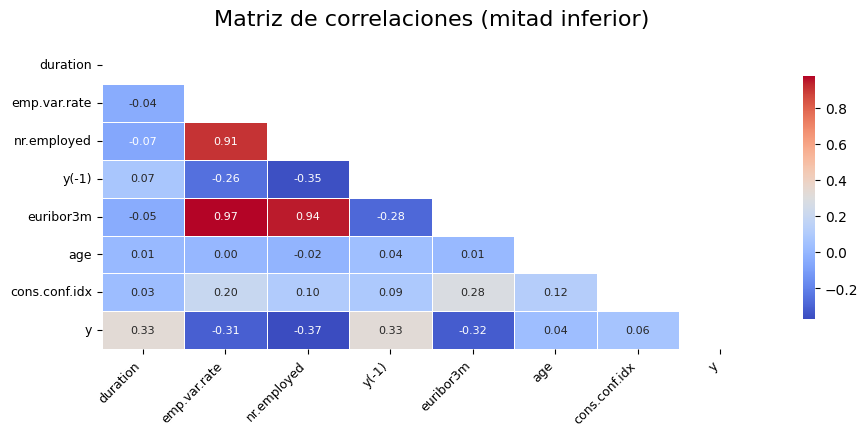

In [82]:
#Análisis de correlaciones entre regresores
x_vif.drop(columns="const", axis=1, inplace=True)
x_vif['y'] = y_train_sel
corr = x_vif.corr()

#Mapa de correlaciones
plt.figure(figsize=(10, 5))
sns.heatmap(
    corr, mask=np.triu(np.ones_like(corr, dtype=bool)), 
    cmap='coolwarm',
    annot=True, fmt=".2f", linewidths=.5,
    cbar_kws={"shrink": .8},
    annot_kws={"size": 8}
)
plt.title("Matriz de correlaciones (mitad inferior)", fontsize=16, pad=15)
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.yticks(fontsize=9)
plt.tight_layout(pad=3.0)
plt.show()

INTERESANTE TESTAR RELACIONES EXISTENTES ENTRE VARIABLES

## 2.4. Cross_validation

Vamos a analizar las siguientes estrategias:

1. Dejamos todas las variables correlacionadas
2. Eliminamos ``emp.var.rate``
3. Eliminamos ``euribor3m``

### A) Concreciones

In [83]:
#Scorings de análisis
scorings=["f1", "recall", "precision"]
metrics1=[]
# Versión 1: todas las características
met1_x=x_vif.drop(columns=["y"])

#Cross validation por cada scoring
for scoring in scorings:
    cv_results1 = cross_val_score(RandomForestClassifier(random_state=42,n_jobs=-1), met1_x, y_train_sel, cv=5, scoring=scoring)
    metrics1.append(float(round(cv_results1.mean()*100, 3)))

In [84]:
#Resultados
metrics2=[]
# Versión 2: eliminamos "emp.var.rate"
met2_x=met1_x.drop(columns="emp.var.rate")

#Cross validation por cada scoring
for scoring in scorings:
    cv_results2 = cross_val_score(RandomForestClassifier(random_state=42,n_jobs=-1), met2_x, y_train_sel, cv=5, scoring=scoring)
    metrics2.append(float(round(cv_results2.mean()*100, 3)))

In [85]:
#Resultados
metrics3=[]
# Versión 3: eliminamos "euribor3m" 
met3_x=met1_x.drop(columns=["euribor3m"])

#Cross validation por cada scoring
for scoring in scorings:
    cv_results3 = cross_val_score(RandomForestClassifier(random_state=42,n_jobs=-1), met3_x, y_train_sel, cv=5, scoring=scoring)
    metrics3.append(float(round(cv_results3.mean()*100, 3)))

In [86]:
# Tabla resumen
pd.DataFrame([metrics1, metrics2, metrics3], index=["Df completo", "- emp.var.rate", "- euribor3m"], columns=scorings).sort_values(by="f1", ascending=False)

,f1,recall,precision
- emp.var.rate,56.474,52.385,61.265
Df completo,55.726,51.633,60.544
- euribor3m,53.744,50.073,58.007


De esta forma, deberemos eliminar ``emp.var.rate``.

C:\Users\jjime\AppData\Local\Temp\ipykernel_17704\3227750785.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_train_final["y"]=y_train_sel


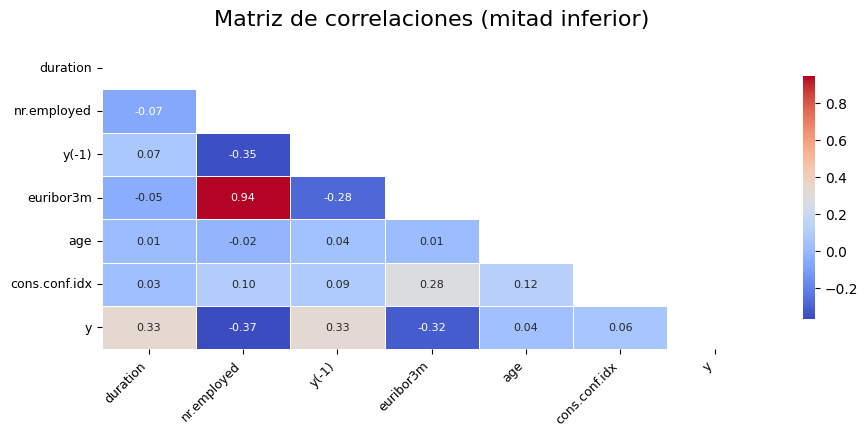

In [87]:
#Definimos variables finales
sel.remove("emp.var.rate")

#Definimos X_train_final
X_train_final=X_train_sel[sel]
X_train_final["y"]=y_train_sel

#Mapa de correlaciones final
plt.figure(figsize=(10, 5))
sns.heatmap(
    X_train_final.corr(), mask=np.triu(np.ones_like(X_train_final.corr(), dtype=bool)), 
    cmap='coolwarm',
    annot=True, fmt=".2f", linewidths=.5,
    cbar_kws={"shrink": .8},
    annot_kws={"size": 8}
)
plt.title("Matriz de correlaciones (mitad inferior)", fontsize=16, pad=15)
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.yticks(fontsize=9)
plt.tight_layout(pad=3.0)
plt.show()

# 3. Modelado

## 3.1. Escalado de datos

### 3.1.1. Preprocesamiento

https://scikit-learn.org/stable/api/sklearn.preprocessing.html

In [88]:
# Definimos características objetivo
## BBDD train
y_train_final=X_train_final["y"]
X_train_final.drop(columns="y", inplace=True)
## BBDD test
X_test_final=X_test_sel[sel]

# Visualizamos resultados
X_train_final.describe().T

C:\Users\jjime\AppData\Local\Temp\ipykernel_17704\3757311835.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_train_final.drop(columns="y", inplace=True)


,count,mean,std,min,25%,50%,75%,max
duration,32441.0,5.152049,0.887686,0.000,4.634729,5.181784,5.749393,7.136483
nr.employed,32441.0,5166.707682,72.444220,4963.600,5099.100000,5191.000000,5228.100000,5228.100000
y(-1),32441.0,0.033538,0.180039,0.000,0.000000,0.000000,0.000000,1.000000
euribor3m,32441.0,3.613460,1.736353,0.634,1.344000,4.857000,4.961000,5.045000
age,32441.0,40.034093,10.433339,17.000,32.000000,38.000000,47.000000,98.000000
cons.conf.idx,32441.0,-40.514143,4.634524,-50.800,-42.700000,-41.800000,-36.400000,-26.900000


De esta forma, vamos a trabajar en el escalado de todas las variables menos la dummy ``y(-1)``.

In [89]:
#Media
med=list(X_train_final.mean())
#Coeficiente variacion
cv=list(X_train_final.std()/X_train_final.mean()*100)
#Mediana
men=list(X_train_final.quantile(0.5))

In [90]:
#Coeficiente de asimetría
asim=list(skew(X_train_final))

#Análisis
asim_an=[]
#Recorremos variables
for x in asim:
    if x>-0.5 and x<0.5: #Simétria
        asim_an.append("Simétrica")
    elif x<-1 or x>1: #Asimétria alta
        asim_an.append("Asimétrica alta")
    else: #Asimétria moderada
        asim_an.append("Asimétrica moderada")

In [91]:
#Coeficiente de curtosis
cur=list(kurtosis(X_train_final))

#Análisis
cur_an=[]
#Recorremos variables
for x in cur:
    if x>-0.5 and x<0.5: #Normal
        cur_an.append("Mesocúrtica")
    elif x<-1 or x>1: # Dist. Plana
        cur_an.append("Platicúrtica")
    else: #Peso importante colas y reisgo de outliers
        cur_an.append("Leptocúrtica")

In [92]:
#Método de escalado
esc=[]
#Recorremos variables
for asi,cu in zip(asim_an, cur_an):
    if asi=="Simétrica":
        if cu=="Leptocúrtica" or cu=="Mesocúrtica":  #Standar scaler
            esc.append("StandardScaler")
        else: #Robust scaler
            esc.append("RobustScaler")
    else: #Robust scaler
        esc.append("RobustScaler")

In [93]:
#AÑADIR DATAFRAME
pd.DataFrame([med, men, cv, asim, asim_an, cur, cur_an, esc], 
             columns=X_train_final.columns, 
             index=["Media", "Mediana", "Coef. Var.", "Asimetría", "Asimetría Int.", "Curtosis", "Curtosis Int.", "Escalado"]).T

,Media,Mediana,Coef. Var.,Asimetría,Asimetría Int.,Curtosis,Curtosis Int.,Escalado
duration,5.152049,5.181784,17.22976,-0.536105,Asimétrica moderada,0.868434,Leptocúrtica,RobustScaler
nr.employed,5166.707682,5191.0,1.402135,-1.039074,Asimétrica alta,-0.01385,Mesocúrtica,RobustScaler
y(-1),0.033538,0.0,536.823844,5.181872,Asimétrica alta,24.851797,Platicúrtica,RobustScaler
euribor3m,3.61346,4.857,48.052369,-0.699446,Asimétrica moderada,-1.420468,Platicúrtica,RobustScaler
age,40.034093,38.0,26.061136,0.794066,Asimétrica moderada,0.829746,Leptocúrtica,RobustScaler
cons.conf.idx,-40.514143,-41.8,-11.439275,0.303822,Simétrica,-0.355741,Mesocúrtica,StandardScaler


### 3.1.2. Robust Scaler

In [94]:
# Instaciamos el escalador
rb_scal=RobustScaler()
# Ajustamos y transformamos para train
train_sc=rb_scal.fit_transform(X_train_final)
## Pasamos a df
X_train_sc=pd.DataFrame(train_sc, columns=X_train_final.columns, index=X_train_final.index)
# Solo transformamos para test (independia base datos)
test_sc=rb_scal.transform(X_test_final)
## Pasamos a df
X_test_sc=pd.DataFrame(test_sc, columns=X_test_final.columns, index=X_test_final.index)

In [95]:
X_train_sc

,duration,nr.employed,y(-1),euribor3m,age,cons.conf.idx
12346,0.428558,0.287597,0.0,0.028200,-0.600000,-0.142857
8564,0.005026,0.287597,0.0,0.001935,0.800000,0.000000
21417,-0.482112,0.287597,0.0,0.029306,-0.600000,0.904762
3315,-0.241444,0.000000,0.0,0.000829,-0.200000,0.857143
33236,0.768023,-0.712403,0.0,-0.985900,0.133333,-0.698413
...,...,...,...,...,...,...
6265,-0.508371,0.000000,0.0,0.000000,-0.266667,0.857143
11284,-0.346286,0.287597,0.0,0.028753,-0.600000,0.000000
38158,0.308317,-1.344961,0.0,-1.134365,2.200000,2.365079
860,0.456259,0.000000,0.0,-0.000276,0.133333,0.857143


## 3.2. Entrenamiento

In [271]:
#Entrenamos el modelo
m_logit = LogisticRegression(random_state=42).fit(X_train_sc, y_train_final)
#Predecimo la probabilidad de compra estimada
y_hat_train=pd.DataFrame(m_logit.predict_proba(X_train_sc)[:,1], columns=["prob"]) #Devuele probabilidad asociada a cada categoria 0(NC), 1(C)

[]

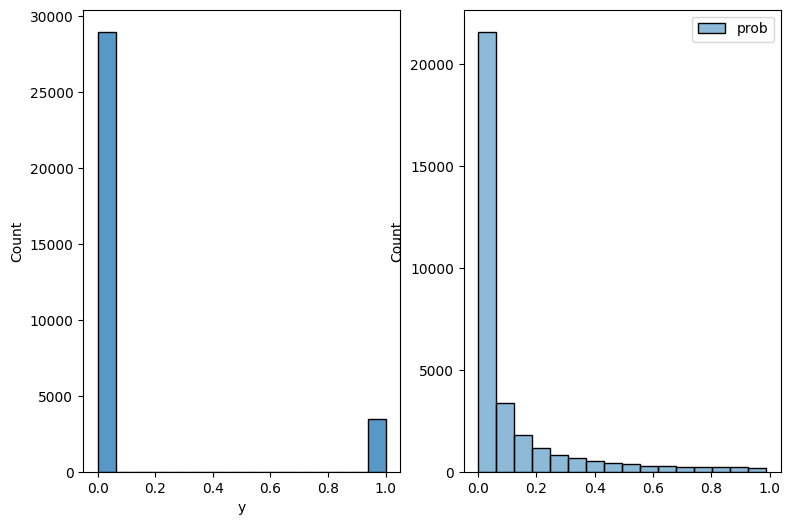

In [272]:
#Comparamos distribuciones
fig, axis = plt.subplots(1, 2, figsize = (9, 6))
sns.histplot(y_train_final, ax=axis[0])
sns.histplot(y_hat_train, bins="sturges", ax=axis[1])
plt.plot()

In [273]:
#Describe de cada variable
pd.concat([y_train_final.describe(), y_hat_train.describe()], axis=1)

,y,prob
count,32441.00,32441.00
mean,0.11,0.11
std,0.31,0.19
min,0.00,0.00
25%,0.00,0.01
50%,0.00,0.02
75%,0.00,0.11
max,1.00,0.99


Observamos como la distribución de porbabilidades de compra se asemaja bastante a los patrones observados. Para deternimar la probabilidad a partir de la cual definimremos a los compradores y no compradores, iteraremos sobre márgenes establecidos en la media de la predicción que nos permita máximizar conjuntamente precision y recall.

In [274]:
#Listas fundamentales
score_lst=[]
margen_lst=[]
cutoff_lst=[]

for i in np.arange(0.8,1.65,0.01):
    #Margen
    margen=i
    margen_lst.append(i)
    #Punto de corte
    cutoff=y_hat_train["prob"].mean()+(margen*y_hat_train["prob"].mean())
    cutoff_lst.append(cutoff)
    #Creamos la variable final
    y_hat_train["pred"]=None
    #Afectado
    y_hat_train.loc[y_hat_train["prob"]>cutoff, "pred"]=1
    #No afectado
    y_hat_train.loc[y_hat_train["prob"]<=cutoff, "pred"]=0
    #Metricas resultante
    recall = recall_score(y_train_final, y_hat_train["pred"].astype("int64"))
    precision = precision_score(y_train_final, y_hat_train["pred"].astype("int64"))
    metrica_opt=(2/3*precision)+(1/3*recall) #Damos más peso a la precision
    score_lst.append(metrica_opt)

#Definimos df con todos los margenes entrenados
result=pd.DataFrame([score_lst,cutoff_lst], columns=margen_lst, index=["Metrica", "Cutoff"]).T
#Optimizacion del margen establecido
print(f"El margen óptimo sobre la desv. est. es de {result["Metrica"].idxmax().round(6)}")
#Definimos el punto de corte objetivo
cutoff_opt=float(result["Cutoff"][result["Metrica"]==result["Metrica"].max()])
print(f"Cuyo punto de corte asignado es {round(cutoff_opt,5)}")

El margen óptimo sobre la desv. est. es de 1.39
Cuyo punto de corte asignado es 0.25477


### 3.3. Evaluación

In [275]:
#Predecimo la probabilidad de compra estimada con el modelo entrenado anteriormente
y_hat_test=pd.DataFrame(m_logit.predict_proba(X_test_sc)[:,1], columns=["prob"])
#Creamos la variable final
y_hat_test["pred"]=None
##Afectados
y_hat_test.loc[y_hat_test["prob"]>cutoff_opt, "pred"]=1
##No afectado
y_hat_test.loc[y_hat_test["prob"]<=cutoff_opt, "pred"]=0

In [276]:
metricas_clas(y_train_final, y_test, y_hat_train["pred"].astype("int64"), y_hat_test["pred"].astype("int64"))

,Accuracy,Recall,Specificity,Precision,F1
Train,0.90,0.62,0.94,0.54,0.58
Test,0.89,0.65,0.92,0.53,0.58
Diferencia,0.01,-0.03,0.01,0.01,-0.01


PUNTO DE CORTE DE PROBABILIDAD ESTIMADA SELECCIONADO: 0.281417


[]

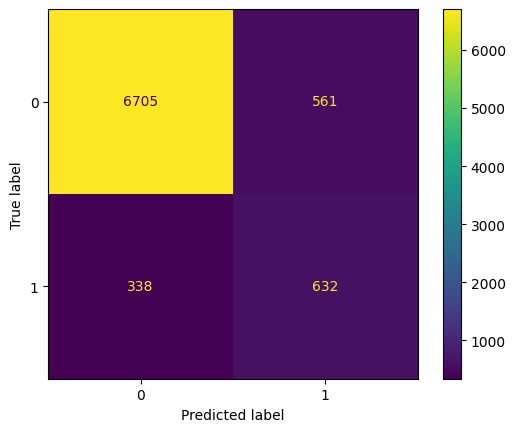

In [277]:
cm1 = confusion_matrix(y_test, y_hat_test["pred"].astype("int64"))
disp = ConfusionMatrixDisplay(confusion_matrix=cm1)
print(f"Punto de corte de probabilidad estimada seleccionado: {cutoff.round(6)}".upper())
disp.plot()
plt.plot()

CONCLUSIONES:

- El modelo entrenado clasifica correctamente al 88,939% de los que contratan y no contratan el deposito.

- Sin embargo, tiene un mejor desempeño dentro de los que no compran (Specificity=92,059%) que entre los que si compran (Recall=65,567%).

- Esto se debe a que el modelo infraestima lo verdaderos compradores en favor de los falsos compradores (52,432%), de forma que solo un 52,432% de los compradores predichos realmente lo es.

Dado los resultados, si la campaña de marketing esta centrada en los clientes potenciales, sería fundamental reenfocar el estudio a inferencia para poder estudiar marginales dada las características de los potenciales clientes.

## 3.4. Optimización de hiperparámetros

### 3.4.1. Búsqueda extensiva

In [278]:
# Tenemos que obtener un conjunto de validación para validar la decisión de qué algoritmo elegir
X_train_sc1, X_val_sc, y_train1, y_val = train_test_split(X_train_sc, y_train_sel, test_size=0.2, random_state=42)

In [279]:
from scipy.stats import loguniform
#Referenciamos el modelo
model = LogisticRegression(max_iter=10000, #Máximo de iteraciones para que el modelo converga
                           solver='saga', #Fijamos saga pues permite elasticnet, l1 y l2
                             random_state=42)

#Definimos espacio de búsqueda
param_dist = {
    # 'C' como distribución log-uniforme (scipy.stats.loguniform), RandomizedSearchCV puede muestrear valores
    'C': loguniform(1e-4, 1e3),           # buscar C en escala log entre 1e-4 y 1e3
    'penalty': ['l1', 'l2', 'elasticnet'],# posibles regularizaciones
    'l1_ratio': [None, 0.25, 0.5, 0.75],  # solo relevante si penalty='elasticnet'
    'class_weight': [None, 'balanced']    # probar ajuste de pesos por clase
}

# Cambiar scoring a métrica de clasificación
random_search = RandomizedSearchCV(
    estimator=model,
    param_distributions=param_dist,
    n_iter=20,                   # aumentar si tienes tiempo
    scoring='roc_auc',           # métrica adecuada para clasificación binaria
    cv=5,
    verbose=4,
    n_jobs=-1,
    random_state=42,
)

# Ejecutamos la búsqueda 
random_search.fit(X_train_sc1, y_train1)
print("Mejores hiperparámetros:")
print(random_search.best_params_)
best_model = random_search.best_estimator_ #Guardamos los resultados

Fitting 5 folds for each of 20 candidates, totalling 100 fits
Mejores hiperparámetros:
{'C': np.float64(0.041858227295469716), 'class_weight': None, 'l1_ratio': 0.5, 'penalty': 'elasticnet'}


### 3.4.2 Búsqueda intensiva

In [280]:
#Espacio de búsqueda más acotado
param_dist = {
    'C': [0.032, 0.042, 0.052],           # buscar C en escala
    'penalty': ['elasticnet'],# posibles regularizaciones
    'l1_ratio': [0.4, 0.5, 0.6],  # solo relevante si penalty='elasticnet'
    'class_weight': [None]
}

# Cambiar scoring a métrica de clasificación
grid_search = GridSearchCV(
    estimator=model,
    param_grid=param_dist,
    scoring='roc_auc',           # métrica adecuada para clasificación binaria
    cv=5,
    verbose=2,
    n_jobs=-1
)

# Ejecutamos la búsqueda 
grid_search.fit(X_train_sc1, y_train1)
print("Mejores hiperparámetros:")
print(grid_search.best_params_)
best_model = grid_search.best_estimator_ #Guardamos los resultados

Fitting 5 folds for each of 9 candidates, totalling 45 fits
Mejores hiperparámetros:
{'C': 0.042, 'class_weight': None, 'l1_ratio': 0.4, 'penalty': 'elasticnet'}


### 3.4.3. Evaluación modelo optimizado

In [281]:
#Reentrenamos con todo el conjunto de entrenamiento
best_model.fit(X_test_sc, y_test)

#Predecimos en train
y_hat_test=pd.DataFrame(best_model.predict_proba(X_test_sc)[:,1], columns=["prob"])
#Creamos la variable final
y_hat_test["pred"]=None
##Afectados
y_hat_test.loc[y_hat_test["prob"]>cutoff_opt, "pred"]=1
##No afectado
y_hat_test.loc[y_hat_test["prob"]<=cutoff_opt, "pred"]=0

#Predecimos en test
y_hat_test=pd.DataFrame(best_model.predict_proba(X_test_sc)[:,1], columns=["prob"])
#Creamos la variable final
y_hat_test["pred"]=None
##Afectados
y_hat_test.loc[y_hat_test["prob"]>cutoff_opt, "pred"]=1
##No afectado
y_hat_test.loc[y_hat_test["prob"]<=cutoff_opt, "pred"]=0

In [282]:
metricas_clas(y_train_final, y_test, y_hat_train["pred"].astype("int64"), y_hat_test["pred"].astype("int64"))

,Accuracy,Recall,Specificity,Precision,F1
Train,0.90,0.62,0.94,0.54,0.58
Test,0.89,0.66,0.92,0.52,0.58
Diferencia,0.01,-0.04,0.02,0.01,-0.01


PUNTO DE CORTE DE PROBABILIDAD ESTIMADA SELECCIONADO: 0.281417


[]

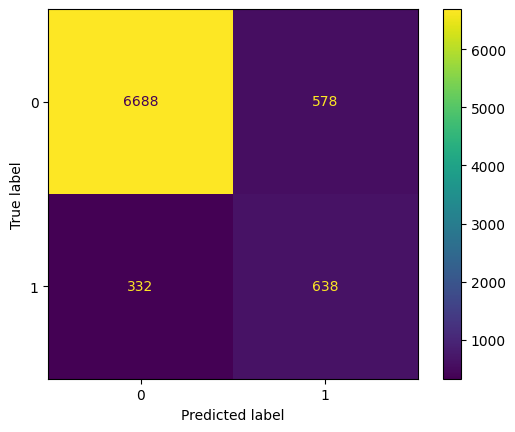

In [283]:
cm2 = confusion_matrix(y_test, y_hat_test["pred"].astype("int64"))
disp = ConfusionMatrixDisplay(confusion_matrix=cm2)
print(f"Punto de corte de probabilidad estimada seleccionado: {cutoff.round(6)}".upper())
disp.plot()
plt.plot()

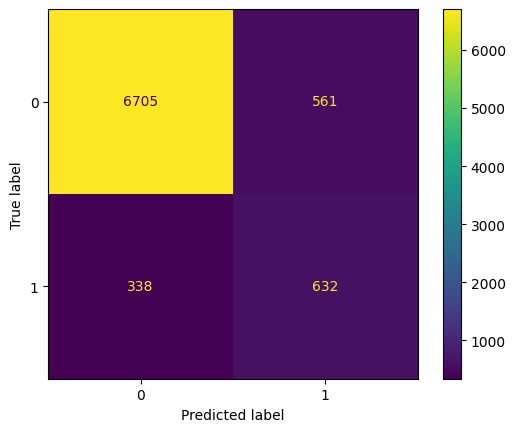

In [284]:
#Comparamos con el modelo anterior
ConfusionMatrixDisplay(confusion_matrix=cm1).plot()

Tras la optimización de los hiperparámetros, se aprecia un incremento en el número de verdaderos compradores.

## 3.5. Ampliación de algoritmos 

In [199]:
from lazypredict.Supervised import LazyClassifier
reg = LazyClassifier(verbose=0, ignore_warnings=False, custom_metric=None)
models, predictions = reg.fit(X_train_sc1, X_val_sc, y_train1, y_val)

  0%|          | 0/32 [00:00<?, ?it/s]

CategoricalNB model failed to execute
Negative values in data passed to CategoricalNB (input X).
FixedThresholdClassifier model failed to execute
FixedThresholdClassifier.__init__() missing 1 required positional argument: 'estimator'
LabelSpreading model failed to execute
Unable to allocate 5.02 GiB for an array with shape (25952, 25952) and data type float64
NuSVC model failed to execute
specified nu is infeasible
SelfTrainingClassifier model failed to execute
You must pass an estimator to SelfTrainingClassifier. Use `estimator`.
StackingClassifier model failed to execute
StackingClassifier.__init__() missing 1 required positional argument: 'estimators'
TunedThresholdClassifierCV model failed to execute
TunedThresholdClassifierCV.__init__() missing 1 required positional argument: 'estimator'


In [200]:
models

,Accuracy,Balanced Accuracy,ROC AUC,F1 Score,Time Taken
Model,,,,,
NearestCentroid,0.81,0.77,0.77,0.83,0.15
BernoulliNB,0.87,0.74,0.74,0.88,0.04
RandomForestClassifier,0.91,0.73,0.73,0.90,8.16
XGBClassifier,0.91,0.73,0.73,0.91,1.06
PassiveAggressiveClassifier,0.89,0.72,0.72,0.89,0.18
ExtraTreesClassifier,0.90,0.72,0.72,0.90,2.16
LGBMClassifier,0.91,0.72,0.72,0.91,1.25
KNeighborsClassifier,0.91,0.72,0.72,0.90,0.42
QuadraticDiscriminantAnalysis,0.89,0.71,0.71,0.89,0.15


Dados los valores predictivos tan limitados, aplicar algunos de estos modelos podría mejorar las predicciones.